In [2]:
import sqlite3
import pandas as pd

# 1. Load CSV into a Pandas DataFrame
df = pd.read_csv('/Telco Customer Churn.zip')

# 2. Connect to an in-memory/file SQLite database inside Colab
conn = sqlite3.connect('churn_database.db')

# 3. Save the DataFrame as a SQL table named 'customer_churn'
df.to_sql('customer_churn', conn, if_exists='replace', index=False)

print("Database created successfully! Table 'customer_churn' is ready for querying.")

Database created successfully! Table 'customer_churn' is ready for querying.


In [3]:
# Check total records and churn distribution using SQL
query = """
SELECT
    Churn,
    COUNT(*) as Total_Customers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customer_churn), 2) as Percentage
FROM customer_churn
GROUP BY Churn;
"""

pd.read_sql_query(query, conn)

,Churn,Total_Customers,Percentage
0,No,5174,73.46
1,Yes,1869,26.54


In [4]:
# Check column names and data types assigned by SQLite
query_schema = """
PRAGMA table_info(customer_churn);
"""
pd.read_sql_query(query_schema, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,customerID,TEXT,0,None,0
1,1,gender,TEXT,0,None,0
2,2,SeniorCitizen,INTEGER,0,None,0
3,3,Partner,TEXT,0,None,0
4,4,Dependents,TEXT,0,None,0
5,5,tenure,INTEGER,0,None,0
6,6,PhoneService,TEXT,0,None,0
7,7,MultipleLines,TEXT,0,None,0
8,8,InternetService,TEXT,0,None,0
9,9,OnlineSecurity,TEXT,0,None,0


In [5]:
# Find records where TotalCharges is blank or empty
query_dirty_data = """
SELECT
    customerID,
    tenure,
    MonthlyCharges,
    TotalCharges
FROM customer_churn
WHERE TRIM(TotalCharges) = '' OR TotalCharges IS NULL;
"""

pd.read_sql_query(query_dirty_data, conn)

,customerID,tenure,MonthlyCharges,TotalCharges
0,4472-LVYGI,0,52.55,
1,3115-CZMZD,0,20.25,
2,5709-LVOEQ,0,80.85,
3,4367-NUYAO,0,25.75,
4,1371-DWPAZ,0,56.05,
5,7644-OMVMY,0,19.85,
6,3213-VVOLG,0,25.35,
7,2520-SGTTA,0,20.00,
8,2923-ARZLG,0,19.70,
9,4075-WKNIU,0,73.35,


In [6]:
# Create a cleaned SQL View with proper numeric types
setup_clean_view = """
CREATE VIEW IF NOT EXISTS clean_customer_churn AS
SELECT
    customerID,
    gender,
    SeniorCitizen,
    Partner,
    Dependents,
    tenure,
    PhoneService,
    MultipleLines,
    InternetService,
    Contract,
    PaymentMethod,
    MonthlyCharges,
    CAST(
        CASE
            WHEN TRIM(TotalCharges) = '' THEN '0.0'
            ELSE TotalCharges
        END AS REAL
    ) AS TotalCharges,
    Churn
FROM customer_churn;
"""

# Execute the view creation
cursor = conn.cursor()
cursor.execute(setup_clean_view)
conn.commit()

print("Clean view 'clean_customer_churn' created successfully!")

Clean view 'clean_customer_churn' created successfully!


In [7]:
# Measure customer churn and financial impact
query_churn_metrics = """
SELECT
    Contract,
    COUNT(customerID) as Total_Customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as Churned_Customers,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(customerID), 2) as Churn_Rate_Percentage,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END), 2) as Lost_Monthly_Revenue
FROM clean_customer_churn
GROUP BY Contract
ORDER BY Churn_Rate_Percentage DESC;
"""

pd.read_sql_query(query_churn_metrics, conn)

,Contract,Total_Customers,Churned_Customers,Churn_Rate_Percentage,Lost_Monthly_Revenue
0,Month-to-month,3875,1655,42.71,120847.10
1,One year,1473,166,11.27,14118.45
2,Two year,1695,48,2.83,4165.30


In [8]:
# Advanced Window Function Query: Rank churned customers & compare against group averages
query_window_func = """
WITH RankedChurners AS (
    SELECT
        customerID,
        Contract,
        PaymentMethod,
        MonthlyCharges,
        -- Calculate average monthly charge for the contract group
        ROUND(AVG(MonthlyCharges) OVER(PARTITION BY Contract), 2) as Avg_Contract_MonthlyCharge,
        -- Calculate difference from the group average
        ROUND(MonthlyCharges - AVG(MonthlyCharges) OVER(PARTITION BY Contract), 2) as Diff_From_Avg,
        -- Rank customers by MonthlyCharges within each Contract tier
        DENSE_RANK() OVER(PARTITION BY Contract ORDER BY MonthlyCharges DESC) as Charge_Rank
    FROM clean_customer_churn
    WHERE Churn = 'Yes'
)
SELECT
    customerID,
    Contract,
    PaymentMethod,
    MonthlyCharges,
    Avg_Contract_MonthlyCharge,
    Diff_From_Avg,
    Charge_Rank
FROM RankedChurners
WHERE Charge_Rank <= 3
ORDER BY Contract, Charge_Rank;
"""

pd.read_sql_query(query_window_func, conn)

,customerID,Contract,PaymentMethod,MonthlyCharges,Avg_Contract_MonthlyCharge,Diff_From_Avg,Charge_Rank
0,2302-ANTDP,Month-to-month,Electronic check,117.45,73.02,44.43,1
1,4361-BKAXE,Month-to-month,Bank transfer (automatic),114.50,73.02,41.48,2
2,9158-VCTQB,Month-to-month,Bank transfer (automatic),113.60,73.02,40.58,3
3,8199-ZLLSA,One year,Bank transfer (automatic),118.35,85.05,33.30,1
4,2889-FPWRM,One year,Bank transfer (automatic),117.80,85.05,32.75,2
5,1444-VVSGW,One year,Credit card (automatic),115.65,85.05,30.60,3
6,9053-JZFKV,Two year,Credit card (automatic),116.20,86.78,29.42,1
7,1555-DJEQW,Two year,Bank transfer (automatic),114.20,86.78,27.42,2
8,5271-YNWVR,Two year,Electronic check,113.15,86.78,26.37,3


/tmp/ipykernel_713/1062436540.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_713/1062436540.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


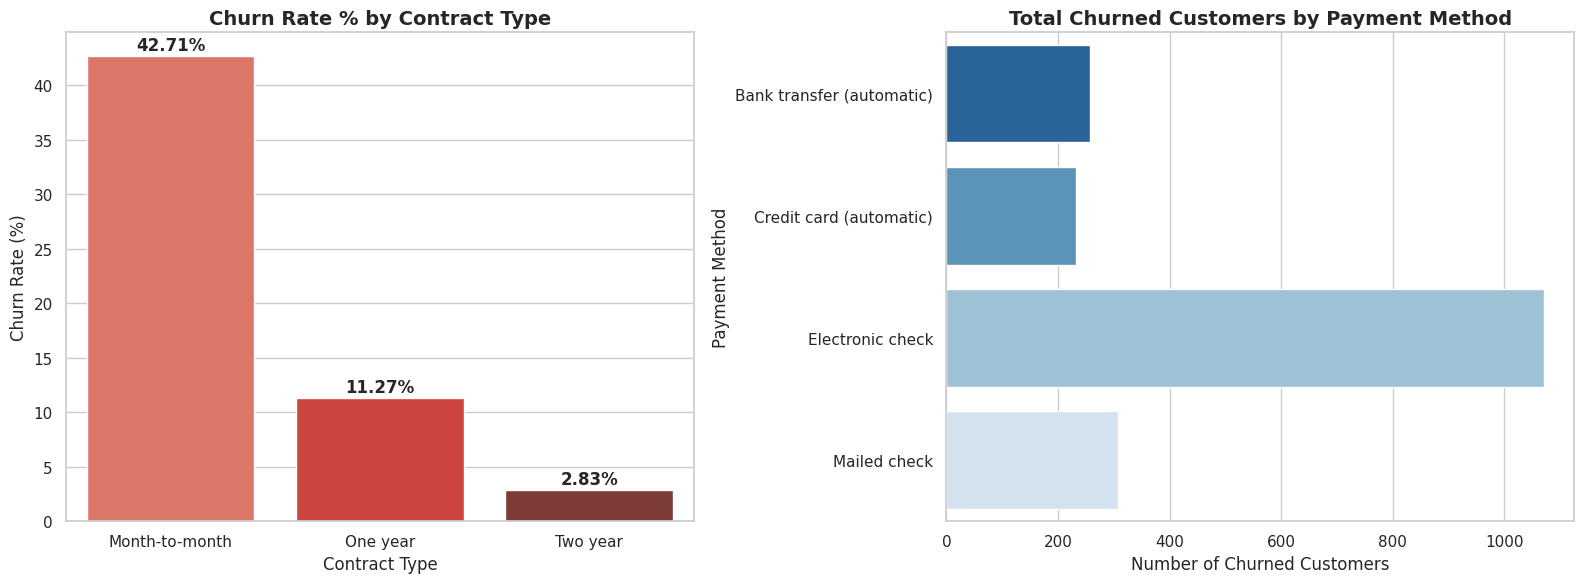

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot 1: Churn Rate by Contract Type
contract_data = pd.read_sql_query("""
    SELECT Contract,
           ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as Churn_Rate
    FROM clean_customer_churn
    GROUP BY Contract
""", conn)

sns.barplot(
    data=contract_data,
    x='Contract',
    y='Churn_Rate',
    ax=axes[0],
    palette='Reds_d'
)
axes[0].set_title('Churn Rate % by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)', fontsize=12)
axes[0].set_xlabel('Contract Type', fontsize=12)

# Annotate bars with values
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()}%",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8),
                     textcoords='offset points', fontweight='bold')

# 2. Plot 2: Churn by Payment Method
payment_data = pd.read_sql_query("""
    SELECT PaymentMethod,
           COUNT(*) as Total_Customers,
           SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as Churned
    FROM clean_customer_churn
    GROUP BY PaymentMethod
""", conn)

sns.barplot(
    data=payment_data,
    x='Churned',
    y='PaymentMethod',
    ax=axes[1],
    palette='Blues_r'
)
axes[1].set_title('Total Churned Customers by Payment Method', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Churned Customers', fontsize=12)
axes[1].set_ylabel('Payment Method', fontsize=12)

plt.tight_layout()
plt.show()